In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save model
import joblib

In [3]:
F_df= pd.read_csv("../data/Fake.csv")
T_df= pd.read_csv("../data/True.csv")

In [4]:
F_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
T_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
T_df.shape

(21417, 4)

In [7]:
F_df.shape

(23481, 4)

In [8]:
print(T_df.columns)
print(F_df.columns)

Index(['title', 'text', 'subject', 'date'], dtype='str')
Index(['title', 'text', 'subject', 'date'], dtype='str')


In [9]:
print(T_df.info())
print(F_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 669.4 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 733.9 KB
None


In [10]:
T_df.describe()


,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


In [11]:
F_df.describe()

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [12]:
print(F_df.isnull().sum())
print()
print(T_df.isnull().sum())

title      0
text       0
subject    0
date       0
dtype: int64

title      0
text       0
subject    0
date       0
dtype: int64


In [13]:
print("Fake News Duplicates:", F_df.duplicated().sum())
print("True News Duplicates:", T_df.duplicated().sum())

Fake News Duplicates: 3
True News Duplicates: 206


In [14]:
F_df["label"] = 0
T_df["label"] = 1

In [15]:
F_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [16]:
T_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [17]:
df = pd.concat([T_df,F_df],ignore_index=True)

In [18]:
df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [19]:
df.tail()

,title,text,subject,date,label
44893,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
44894,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
44895,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
44896,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
44897,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [20]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [21]:
df.head()

,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


In [22]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(209)

In [24]:
df = df.drop_duplicates()

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df["label"].value_counts()

label
0    23478
1    21211
Name: count, dtype: int64

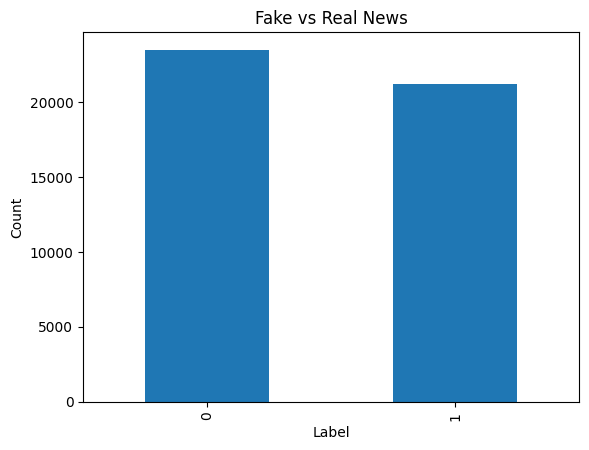

In [27]:
df["label"].value_counts().plot(kind="bar")
plt.title("Fake vs Real News")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [28]:
df["subject"].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

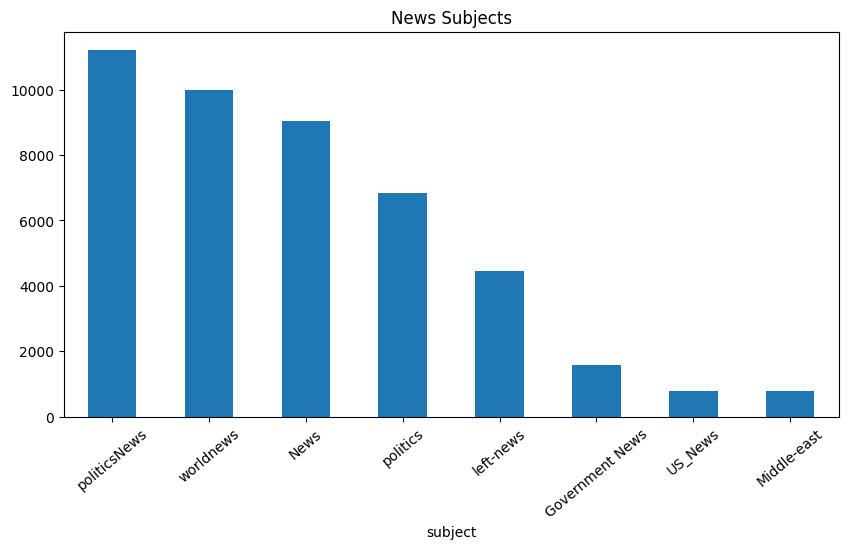

In [29]:
df["subject"].value_counts().plot(kind="bar", figsize=(10,5))
plt.xticks(rotation=40)
plt.title("News Subjects")
plt.show()

In [30]:
df["text_length"] = df["text"].apply(len)

In [31]:
df["text_length"].describe()

count    44689.000000
mean      2467.098682
std       2173.612347
min          1.000000
25%       1232.000000
50%       2185.000000
75%       3101.000000
max      51794.000000
Name: text_length, dtype: float64

In [32]:
df.groupby("label")["text_length"].mean()

label
0    2547.555882
1    2378.042337
Name: text_length, dtype: float64

In [33]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aasif\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
print(stop_words)

{'few', 'herself', 'some', 'out', 'd', 'is', "i'm", 'here', 'there', 'under', 'having', "mustn't", 'both', 'by', 'an', 'couldn', 'can', 'if', 'so', 'yours', "didn't", 'all', 'hasn', 'we', 'been', 'his', 'did', "it's", 'and', "he's", "i've", 'against', 'not', "aren't", "hasn't", 'when', "you've", "i'll", 'down', 'most', 'on', 'does', 'o', 'our', 'about', "doesn't", 'then', 'into', 'below', 'before', 'it', 'once', 'a', "you'll", 'i', 'each', 'but', 'as', 'now', 'should', 'above', 'do', 'with', 'doesn', 'me', 'just', 'the', 'at', "she'll", 'y', 'for', "won't", 'won', "she'd", "shan't", "he'd", "i'd", 'll', "wouldn't", 'yourselves', 'were', 'while', 'shan', 'again', 'himself', 'myself', "should've", 'or', 'from', "hadn't", 'wasn', 'other', "don't", "we've", 'don', "he'll", 'why', 'nor', 'didn', "couldn't", 'you', "it'll", 're', "they've", 'only', 'theirs', 'too', 'very', 'wouldn', 'ourselves', 'ours', 'be', 'that', "they're", 'ain', 'after', 'because', 'same', "they'll", 'they', 't', 'whic

In [35]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    filtered_words = []
    for word in words:
        if word not in stop_words:
            filtered_words.append(stemmer.stem(word))

    return " ".join(filtered_words)

In [36]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [37]:
print("Original Text:\n")
print(df["text"][1])

print("\n" + "=" * 100 + "\n")

print("Clean Text:\n")
print(df["clean_text"][1])

Original Text:

Now that Donald Trump is the presumptive GOP nominee, it s time to remember all those other candidates who tried so hard to beat him in the race to the White House. After all, how can we forget all the missteps, gaffes, weirdness, and sheer idiocies of such candidates as Jeb Bush, Marco Rubio, John Kasich, Ted Cruz, Ben Carson, and Carly Fiorina?There s a video making the rounds on Twitter that does just that, and eulogizes three of these failed candidates as though they re dead (and the GOP itself might as well be dead at this point anyway). Appropriately titled,  A Eulogy for the GOP,  people make short speeches about each of these candidates.Once past the man who actually says Jeb Bush was qualified to be president, there are fake tears, with journalist and comedienne Francesca Fiorentini saying: Dearly beloved, we re gathered here today to commemorate the candidates that are no longer with us. One man, speaking to an amusing, circus-y rendition of Chopin s Funeral M

In [38]:
x=df["clean_text"]
y = df["label"]

In [39]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
tfidf = TfidfVectorizer(max_features=5000)

In [41]:
x_train = tfidf.fit_transform(x_train)

In [42]:
x_test = tfidf.transform(x_test)

In [43]:
print(tfidf.get_feature_names_out()[:20])

['10' '100' '1000' '10000' '100000' '11' '12' '120' '13' '130' '14' '15'
 '150' '16' '17' '18' '19' '1950' '1960' '1967']


In [45]:
model = LogisticRegression(max_iter=5000)

In [46]:
model.fit(x_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [47]:
y_pred = model.predict(x_test)

In [48]:
print(y_pred[:10])

[1 1 0 0 0 1 0 0 1 1]


In [49]:
print(y_test[:10].values)

[1 1 0 0 0 1 0 0 1 1]


In [50]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9893712239874692


In [51]:
confusion_matrix(y_test,y_pred)

array([[4663,   61],
       [  34, 4180]])

In [52]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4724
           1       0.99      0.99      0.99      4214

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



In [53]:
nb_model = MultinomialNB()


In [54]:
nb_model.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[18754.,16997.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.65,-0.74]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[70.33,46.76,13.59,...,26.88, 8.7 , 0. ], [67.79,34.34,15.82,...,41.43, 3.56,29.03]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[ -7.72, -8.12, -9.31,..., -8.66, -9.72,-11.99], [ -7.69, -8.36, -9.1 ,..., -8.17,-10.4 , -8.52]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [55]:
nb_y_pred=nb_model.predict(x_test)

In [56]:
nb_accuracy = accuracy_score(y_test,nb_y_pred)
print(accuracy)

0.9893712239874692


In [57]:
print(classification_report(y_test,nb_y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      4724
           1       0.93      0.95      0.94      4214

    accuracy                           0.94      8938
   macro avg       0.94      0.94      0.94      8938
weighted avg       0.94      0.94      0.94      8938



In [58]:
svc_model = LinearSVC()

In [59]:
svc_model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [60]:
svc_y_pred = svc_model.predict(x_test)

In [61]:
accuracy_score(y_test,svc_y_pred)


0.9963078988588051

In [63]:
print(classification_report(y_test,svc_y_pred,digits=6))

              precision    recall  f1-score   support

           0   0.997244  0.995766  0.996505      4724
           1   0.995262  0.996915  0.996088      4214

    accuracy                       0.996308      8938
   macro avg   0.996253  0.996341  0.996296      8938
weighted avg   0.996309  0.996308  0.996308      8938



In [64]:
cm = confusion_matrix(y_test, svc_y_pred)
print(cm)

[[4704   20]
 [  13 4201]]


In [66]:
joblib.dump(svc_model, "fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']